In [1]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import yfinance as yf

from datetime import date, datetime, time, timezone

def get_stock_data(ticker, start, end):
    data = yf.download(ticker, start=start, end=end, auto_adjust=False)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    data = data.loc[:, ~data.columns.duplicated()]
    data = data.reset_index()
    data["Ticker"] = ticker
    return data
    
ticker = 'DIS'
start = datetime(2025, 1, 1)
end = datetime.today()


In [2]:
d = get_stock_data(ticker, start, end)
d.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
0,2025-01-02,108.774353,110.820000,112.199997,110.169998,111.699997,5688100,DIS
1,2025-01-03,109.108078,111.160004,111.540001,110.180000,111.370003,5393100,DIS
2,2025-01-06,109.000114,111.050003,112.849998,110.870003,111.470001,6274400,DIS
3,2025-01-07,109.333832,111.389999,113.739998,111.290001,112.150002,7878800,DIS
4,2025-01-08,107.733917,109.760002,111.110001,108.639999,111.000000,7805300,DIS


In [3]:
d = d.pivot(index="Date", columns="Ticker", values="Close")
d.head()

Ticker,DIS
Date,
2025-01-02,110.820000
2025-01-03,111.160004
2025-01-06,111.050003
2025-01-07,111.389999
2025-01-08,109.760002


In [4]:
SPY = get_stock_data("SPY", start, end)
IYW = get_stock_data("IYW", start, end)
VT = get_stock_data("VT", start, end)
DBA = get_stock_data("DBA", start, end)
TLT = get_stock_data("TLT", start, end)
PDBC = get_stock_data("PDBC", start, end)
IAU = get_stock_data("IAU", start, end)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [5]:
SPY = SPY.reset_index().pivot(index="Date", columns="Ticker", values="Close")
IYW = IYW.reset_index().pivot(index="Date", columns="Ticker", values="Close")
VT = VT.reset_index().pivot(index="Date", columns="Ticker", values="Close")
DBA = DBA.reset_index().pivot(index="Date", columns="Ticker", values="Close")
TLT = TLT.reset_index().pivot(index="Date", columns="Ticker", values="Close")
PDBC = PDBC.reset_index().pivot(index="Date", columns="Ticker", values="Close")
IAU = IAU.reset_index().pivot(index="Date", columns="Ticker", values="Close")

In [6]:
stock = pd.concat([SPY, IYW, VT, DBA, TLT, PDBC, IAU],
                  axis=1,
                  join='outer')
stock.head()

Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Date,,,,,,,
2025-01-02,584.640015,159.550003,117.239998,26.620001,87.570000,13.13,50.189999
2025-01-03,591.950012,162.369995,118.449997,26.490000,87.290001,13.05,49.790001
2025-01-06,595.359985,164.869995,119.180000,26.430000,86.900002,13.08,49.740002
2025-01-07,588.630005,161.100006,118.010002,26.500000,85.919998,13.14,50.009998
2025-01-08,589.489990,161.039993,118.050003,26.360001,86.029999,13.12,50.290001


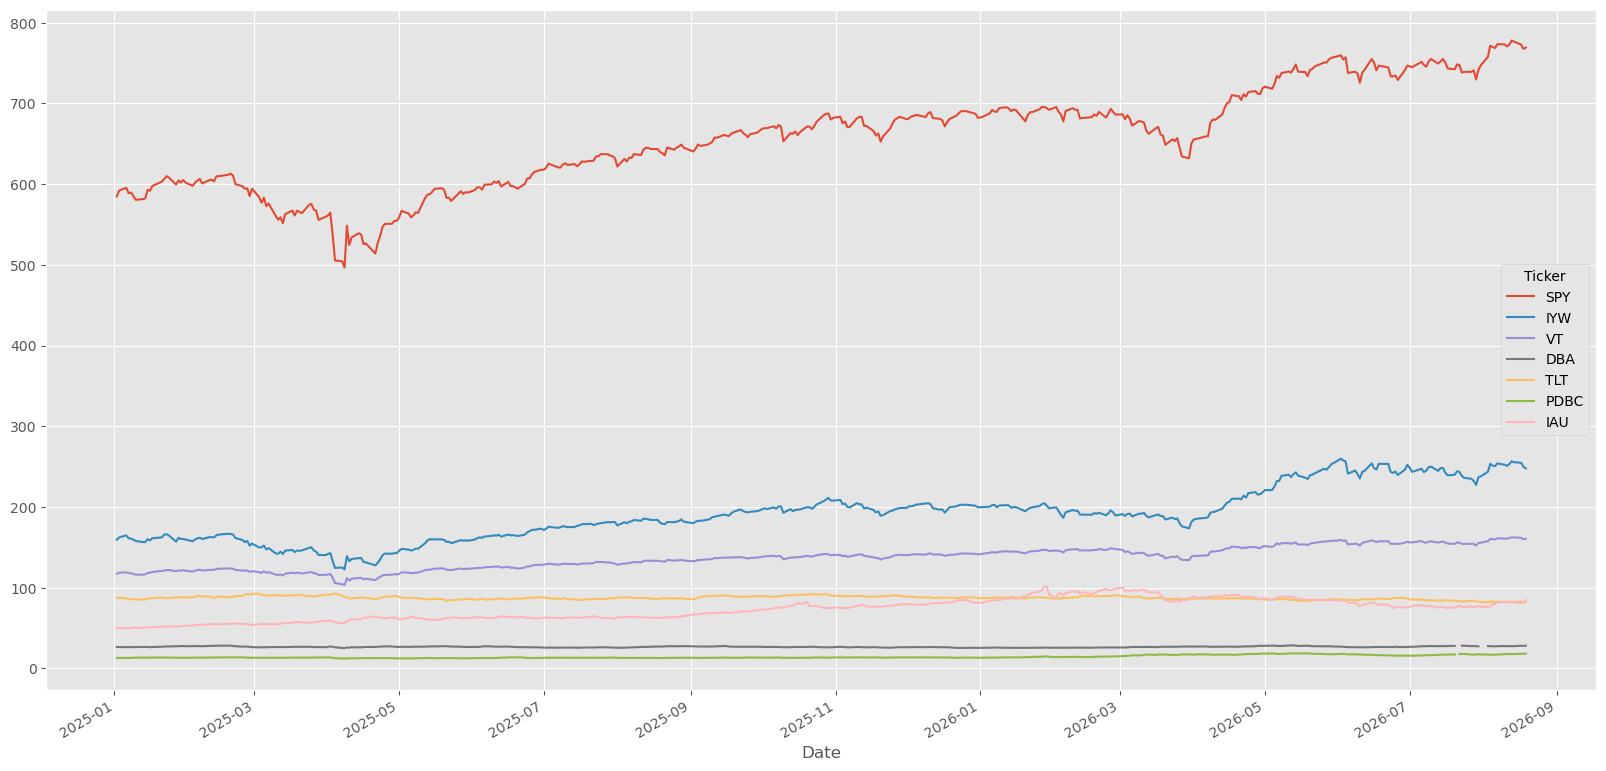

In [7]:
plt.style.use('ggplot')
stock.plot(figsize = (20, 10))
plt.show()

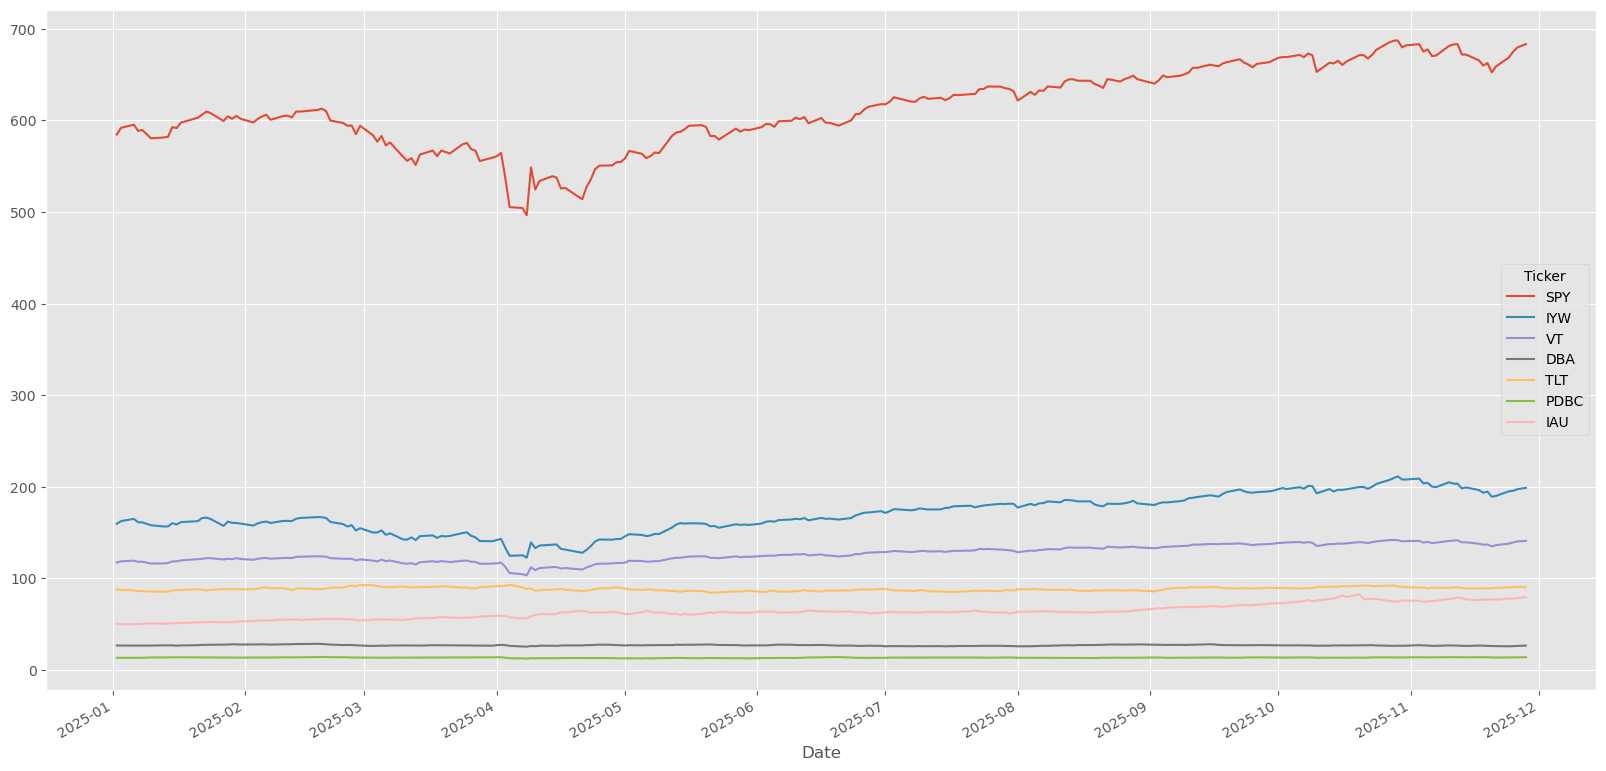

In [8]:
macro_shock = stock['2025-1-1':'2025-11-30']
plt.style.use('ggplot')
macro_shock.plot(figsize = (20, 10))
plt.show()

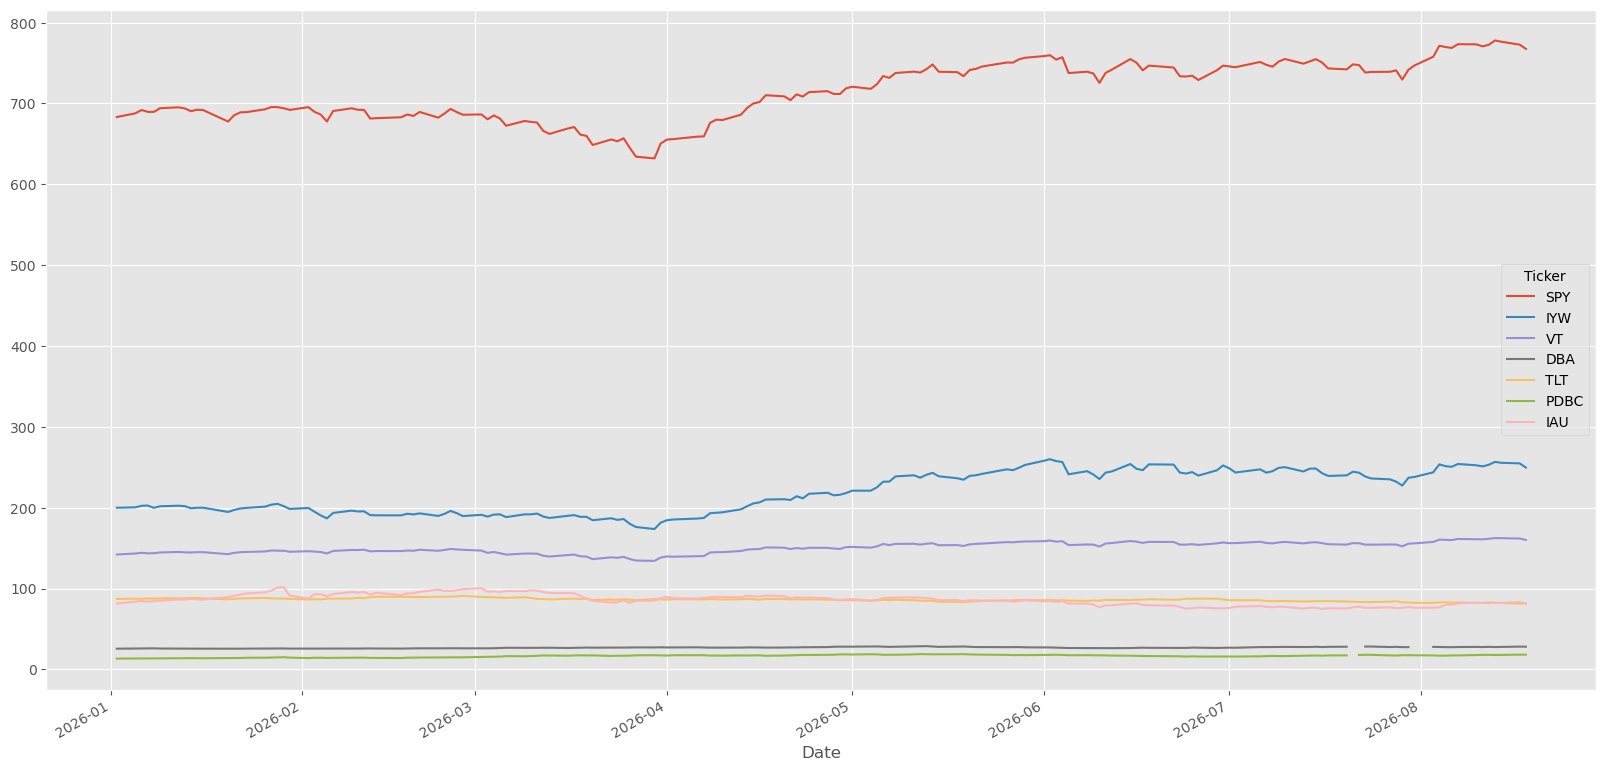

In [9]:
macro_shock = stock['2026-1-1':'2026-8-18']
plt.style.use('ggplot')
macro_shock.plot(figsize = (20, 10))
plt.show()

In [10]:
macro_shock = stock['2025-1-1':'2025-11-30']
x = macro_shock.index
s_y = macro_shock[['SPY']]
i_y = macro_shock[['IAU']]
d_y = macro_shock[['DBA']]
t_y = macro_shock[['TLT']]

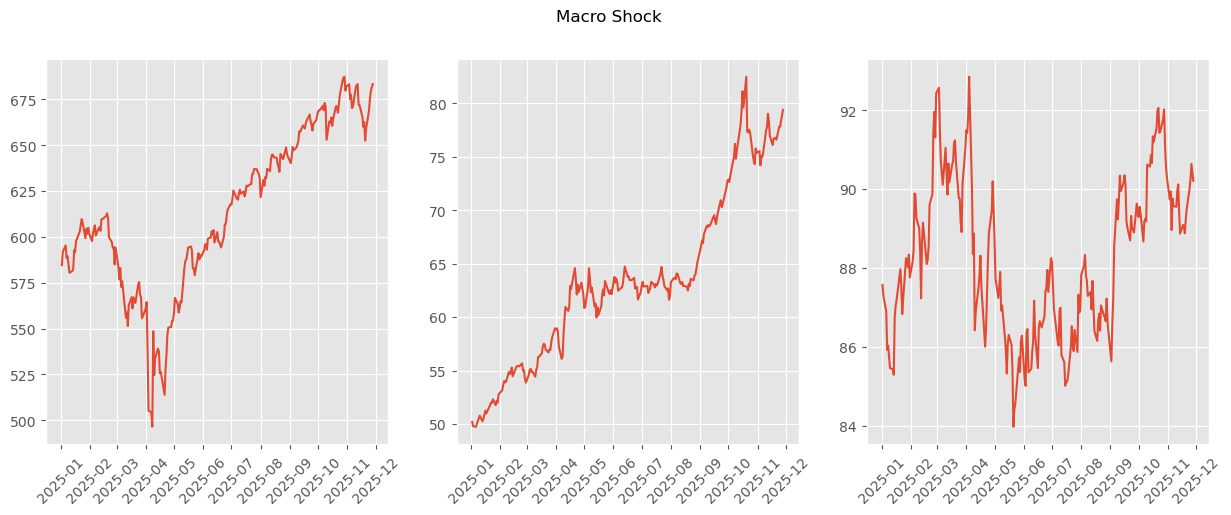

In [11]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].plot(x, s_y)
axs[1].plot(x, i_y)
axs[2].plot(x, t_y)

for ax in axs:
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Macro Shock')
plt.show()

In [12]:
ticker  = 'PDBC'
start = datetime(2025,1,1)
end = datetime.today()

df = get_stock_data(ticker, start, end)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
0,2025-01-02,12.639312,13.13,13.200,13.100,13.10,7044000,PDBC
1,2025-01-03,12.562302,13.05,13.100,13.040,13.10,2969000,PDBC
2,2025-01-06,12.591181,13.08,13.200,13.065,13.16,5883300,PDBC
3,2025-01-07,12.648938,13.14,13.180,13.133,13.15,3053200,PDBC
4,2025-01-08,12.629685,13.12,13.175,13.070,13.14,4955200,PDBC


In [13]:
df = df.drop(['Ticker', 'High', 'Low', 'Open', 'Close', 'Adj Close'], axis=1)
df.head()

Price,Date,Volume
0,2025-01-02,7044000
1,2025-01-03,2969000
2,2025-01-06,5883300
3,2025-01-07,3053200
4,2025-01-08,4955200


<function matplotlib.pyplot.show(close=None, block=None)>

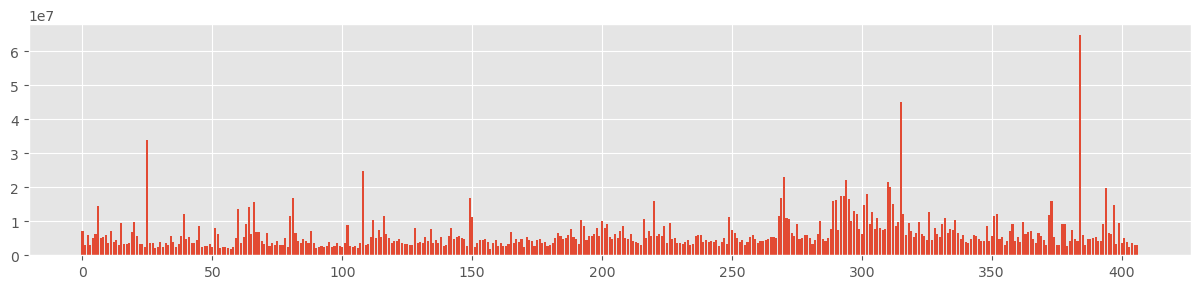

In [14]:
x = df.index
y = df['Volume']
plt.figure(figsize = (15,3))
plt.bar(x,y)
plt.show

[*********************100%***********************]  1 of 1 completed


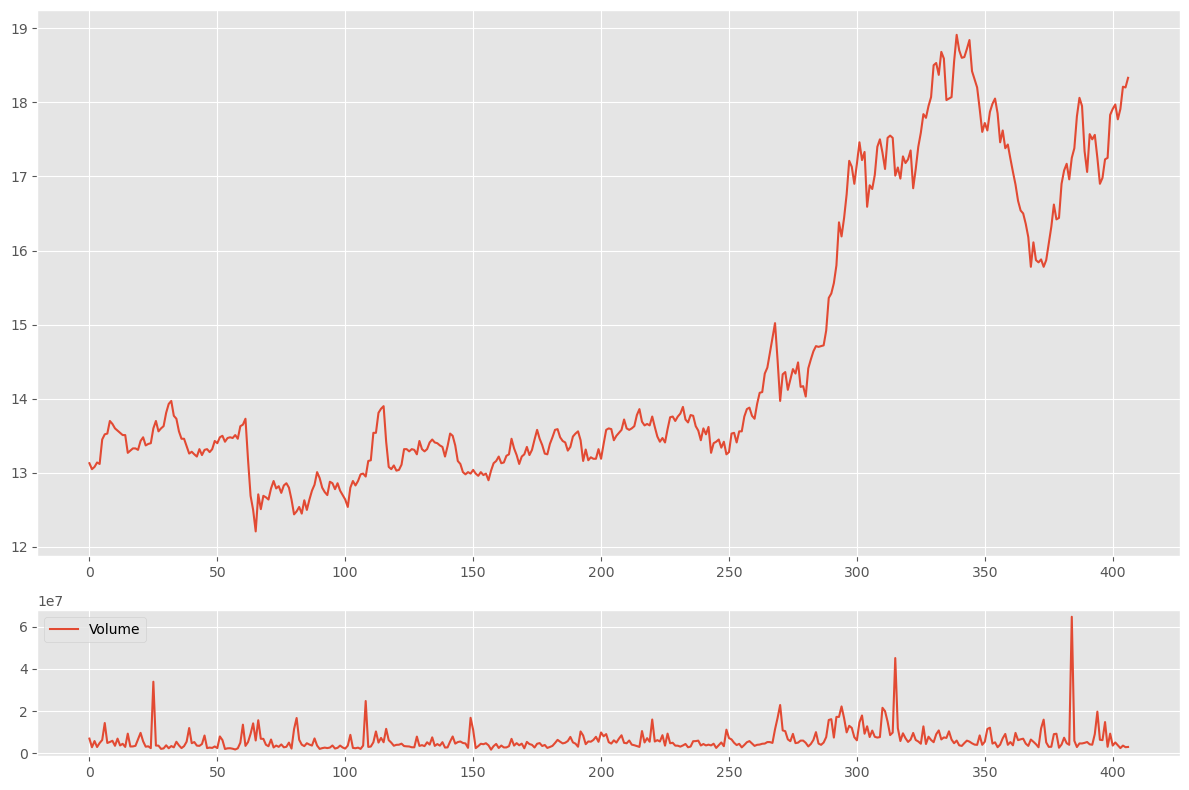

In [15]:
ticker  = 'PDBC'
start = datetime(2025,1,1)
end = datetime.today()

df = get_stock_data(ticker, start, end)

fig = plt.figure(figsize=(12,8))
top_grid = plt.subplot2grid((4,4), (0,0), rowspan=3, colspan=4 )
bottom_grid = plt.subplot2grid((4,4), (3,0), rowspan=1, colspan=4 )

top_grid.plot(df.index, df['Close'], label = 'Close')
bottom_grid.plot(df.index, df['Volume'], label = 'Volume')

plt.tight_layout()

plt.legend()
plt.show()

In [16]:
stock.head()

Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Date,,,,,,,
2025-01-02,584.640015,159.550003,117.239998,26.620001,87.570000,13.13,50.189999
2025-01-03,591.950012,162.369995,118.449997,26.490000,87.290001,13.05,49.790001
2025-01-06,595.359985,164.869995,119.180000,26.430000,86.900002,13.08,49.740002
2025-01-07,588.630005,161.100006,118.010002,26.500000,85.919998,13.14,50.009998
2025-01-08,589.489990,161.039993,118.050003,26.360001,86.029999,13.12,50.290001


In [17]:
stock['SPY']

Date
2025-01-02    584.640015
2025-01-03    591.950012
2025-01-06    595.359985
2025-01-07    588.630005
2025-01-08    589.489990
                 ...    
2026-08-13    777.880005
2026-08-14    776.340027
2026-08-17    772.669983
2026-08-18    767.450012
2026-08-19    769.059998
Name: SPY, Length: 408, dtype: float64

In [18]:
stock['SPY'].shift(1)

Date
2025-01-02           NaN
2025-01-03    584.640015
2025-01-06    591.950012
2025-01-07    595.359985
2025-01-08    588.630005
                 ...    
2026-08-13    772.489990
2026-08-14    777.880005
2026-08-17    776.340027
2026-08-18    772.669983
2026-08-19    767.450012
Name: SPY, Length: 408, dtype: float64

In [19]:
spy_dayily_pc = (stock['SPY'] / stock['SPY'].shift(1)-1) * 100
spy_dayily_pc

Date
2025-01-02         NaN
2025-01-03    1.250342
2025-01-06    0.576058
2025-01-07   -1.130405
2025-01-08    0.146099
                ...   
2026-08-13    0.697746
2026-08-14   -0.197971
2026-08-17   -0.472737
2026-08-18   -0.675576
2026-08-19    0.209784
Name: SPY, Length: 408, dtype: float64

<Axes: xlabel='Date'>

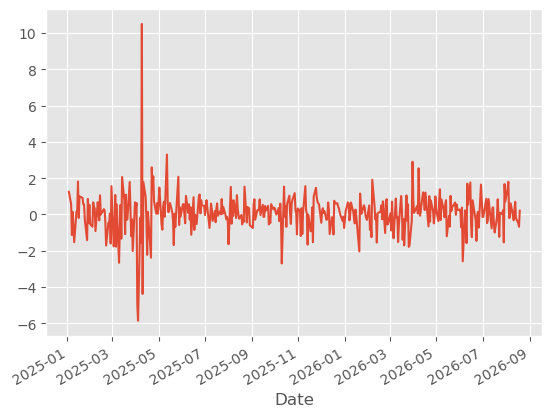

In [20]:
spy_dayily_pc.plot()

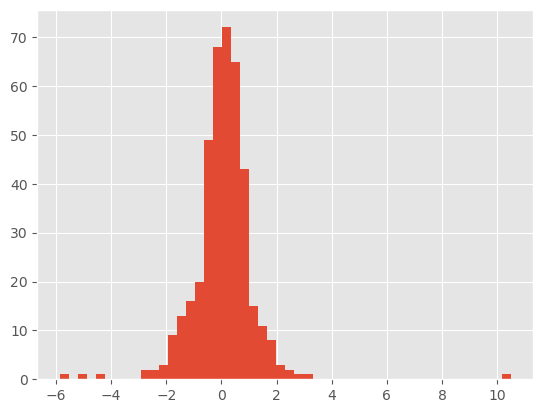

In [24]:
#spy_daily_pc = (stock['SPY']/stock['SPY'].shift(1)-1) * 100
#spy_daily_pc.iloc[0] = 0
plt.hist(spy_dayily_pc, bins = 50)
plt.show()

In [25]:
stock_dayily_pc = (stock-stock.shift(1))/stock.shift(1) * 100
stock_dayily_pc.head()

Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Date,,,,,,,
2025-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-03,1.250342,1.767466,1.032070,-0.488359,-0.319743,-0.609291,-0.796967
2025-01-06,0.576058,1.539693,0.616297,-0.226499,-0.446786,0.229883,-0.100420
2025-01-07,-1.130405,-2.286643,-0.981707,0.264849,-1.127737,0.458719,0.542816
2025-01-08,0.146099,-0.037252,0.033896,-0.528300,0.128027,-0.152210,0.559893


In [28]:
stock_d_cr = stock_dayily_pc.cumsum()
stock_d_cr

Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Date,,,,,,,
2025-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-03,1.250342,1.767466,1.032070,-0.488359,-0.319743,-0.609291,-0.796967
2025-01-06,1.826399,3.307159,1.648367,-0.714857,-0.766529,-0.379408,-0.897387
2025-01-07,0.695994,1.020516,0.666660,-0.450008,-1.894266,0.079311,-0.354571
2025-01-08,0.842093,0.983264,0.700556,-0.978307,-1.766239,-0.072900,0.205322
...,...,...,...,...,...,...,...
2026-08-13,31.002872,53.528118,34.753407,3.017744,-4.860883,30.692975,53.933733
2026-08-14,30.804900,53.103317,34.667195,3.560828,-5.526818,31.480816,54.545129
2026-08-17,30.332164,52.825428,34.408337,4.893197,-6.367874,33.155854,55.553882


<Axes: xlabel='Date'>

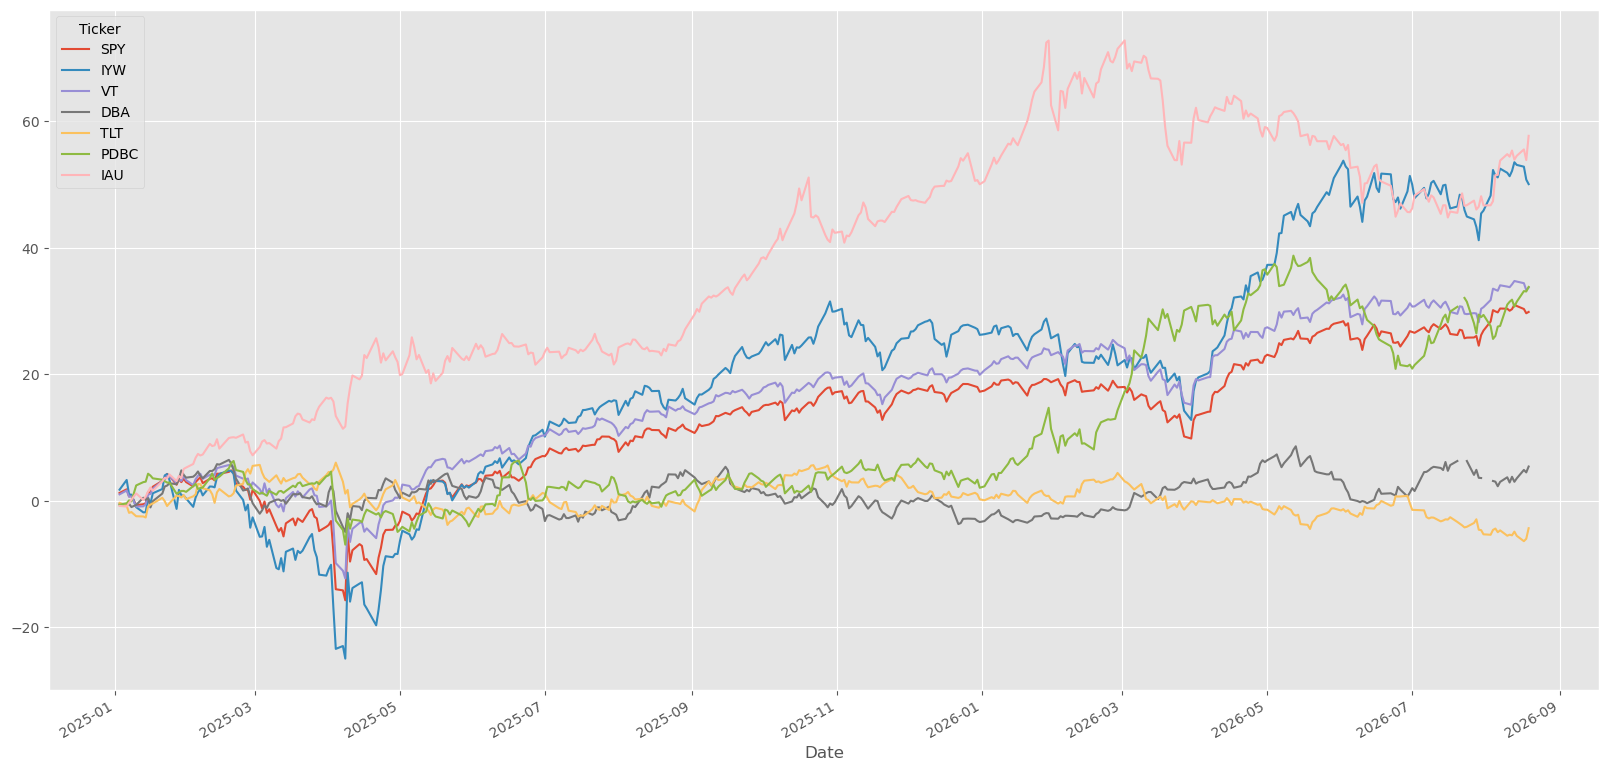

In [31]:
stock_d_cr.plot(figsize=(20,10))

In [33]:
df_corr = stock_dayily_pc.corr()
df_corr

Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Ticker,,,,,,,
SPY,1.000000,0.920233,0.964576,0.263690,0.163009,0.099347,0.155241
IYW,0.920233,1.000000,0.897176,0.233269,0.082734,0.105130,0.175361
VT,0.964576,0.897176,1.000000,0.278055,0.203218,0.055493,0.276063
DBA,0.263690,0.233269,0.278055,1.000000,0.002219,0.397334,0.114012
TLT,0.163009,0.082734,0.203218,0.002219,1.000000,-0.249586,0.079606
PDBC,0.099347,0.105130,0.055493,0.397334,-0.249586,1.000000,0.265039
IAU,0.155241,0.175361,0.276063,0.114012,0.079606,0.265039,1.000000


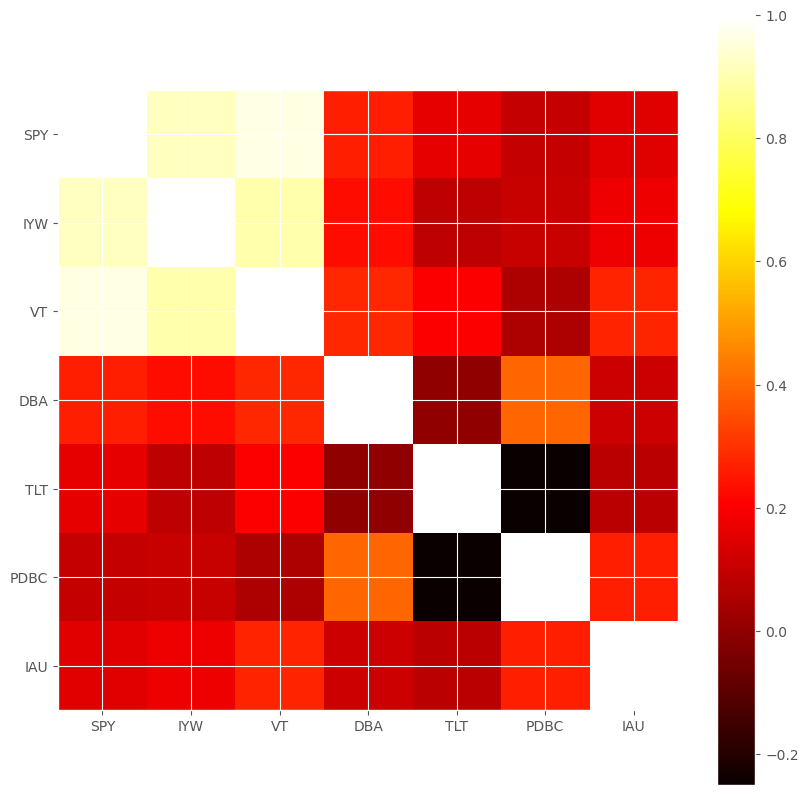

In [35]:
plt.imshow(df_corr, cmap='hot', interpolation='none')
plt.colorbar()
plt.xticks(range(len(df_corr)), df_corr.columns)
plt.yticks(range(len(df_corr)), df_corr.columns)

plt.gcf().set_size_inches(10,10)

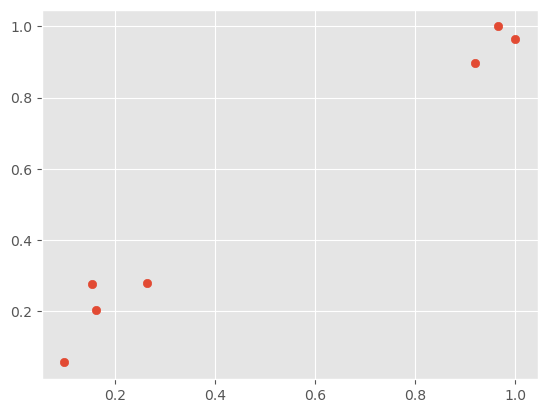

In [36]:
plt.scatter(df_corr.SPY, df_corr.VT)
plt.show()

In [38]:
periods =  75

vol = stock_dayily_pc.rolling(window = periods).std()

vol

Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Date,,,,,,,
2025-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2026-08-13,0.839930,1.872766,0.958480,NaN,0.583089,NaN,1.545183
2026-08-14,0.837792,1.864360,0.955461,NaN,0.586987,NaN,1.533669
2026-08-17,0.840447,1.865330,0.954935,NaN,0.588101,NaN,1.534011


<Axes: xlabel='Date'>

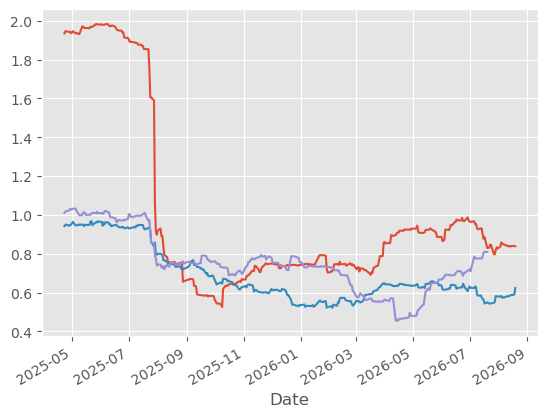

In [39]:
vol["SPY"].plot()
vol["TLT"].plot()
vol["DBA"].plot()